# **XGBOOST**


Notebook ini membangun model XGBoost dengan workflow ABC:

## Tahap A - Baseline Model Development
- Menggunakan fixed hyperparameters yang dipilih berdasarkan karakteristik data return harian.
- Evaluasi baseline full feature set pada validation set.

## Tahap B - Ablation Study
- Menggunakan hyperparameter yang sama.
- Membandingkan kontribusi kelompok fitur:
  - Full
  - Without Group 1: Dollar & rates
  - Without Group 2: Risk sentiment
  - Without Group 3: Commodity / inflation proxy
  - Gold-only

## Tahap C - Final Test Evaluation
- Menggunakan package fitur terbaik dari validation.
- Retrain pada train + validation.
- Evaluasi sekali pada test set.

Metrik:
- MAE
- RMSE
- Directional Accuracy

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Afzi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Config**

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "xgboost_5d"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_xgb_5d.csv"
VAL_PATH = DATA_DIR / "val_xgb_5d.csv"
TEST_PATH = DATA_DIR / "test_xgb_5d.csv"

DATE_COL = "DATE"
TARGET_DATE_COL = "TARGET_DATE"
TARGET_COL = "TARGET_5D"
DIRECTION_COL = "TARGET_DIRECTION"

RANDOM_STATE = 42
N_TRIALS = 100
N_SPLITS = 5
GAP = 5
TARGET_SCALE = 100.0

CORE_FEATURE_BASES = [
    "GOLD_RET",
    "DXY_RET",
    "SP500_RET",
    "OIL_RET",
    "US10Y_CHANGE",
    "VIX_LEVEL",
]

LAGS = [1, 2, 3, 4, 5, 6, 7]

# G1 - Dollar and rates
GROUP_1_DOLLAR_RATES = ["DXY_RET", "US10Y_CHANGE"]

# G2 - Risk sentiment
GROUP_2_RISK = ["SP500_RET", "VIX_LEVEL"]

# G3 - Commodity proxy
GROUP_3_COMMODITY = ["OIL_RET"]

print("DATA_DIR    :", DATA_DIR)
print("RESULTS_DIR :", RESULTS_DIR)

DATA_DIR    : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\data\processed
RESULTS_DIR : C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d


### **Load Data**

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df[TARGET_DATE_COL] = pd.to_datetime(df[TARGET_DATE_COL])
    df.sort_values(DATE_COL, inplace=True)
    df.reset_index(drop=True, inplace=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train: (3256, 52)
Val  : (250, 52)
Test : (503, 52)


,DATE,TARGET_DATE,GOLD_RET,DXY_RET,SP500_RET,OIL_RET,US10Y_CHANGE,VIX_LEVEL,TARGET_5D,TARGET_DIRECTION,...,US10Y_CHANGE_LAG5,US10Y_CHANGE_LAG6,US10Y_CHANGE_LAG7,VIX_LEVEL_LAG1,VIX_LEVEL_LAG2,VIX_LEVEL_LAG3,VIX_LEVEL_LAG4,VIX_LEVEL_LAG5,VIX_LEVEL_LAG6,VIX_LEVEL_LAG7
0,2010-01-14,2010-01-22,0.005456,-0.001561,0.002426,-0.003264,-0.049,17.629999,-0.046736,0,...,0.014,0.053,-0.086,17.850000,18.250000,17.549999,18.129999,19.059999,19.160000,19.350000
1,2010-01-15,2010-01-25,-0.010940,0.007689,-0.010823,-0.017508,-0.058,17.910000,-0.030882,0,...,-0.014,0.014,0.053,17.629999,17.850000,18.250000,17.549999,18.129999,19.059999,19.160000
2,2010-01-19,2010-01-26,0.008495,0.002328,0.012500,0.013077,0.031,17.580000,-0.036676,0,...,0.010,-0.014,0.014,17.910000,17.629999,17.850000,18.250000,17.549999,18.129999,19.059999
3,2010-01-20,2010-01-27,-0.024041,0.010839,-0.010598,-0.017717,-0.048,18.680000,-0.025083,0,...,-0.099,0.010,-0.014,17.580000,17.910000,17.629999,17.850000,18.250000,17.549999,18.129999
4,2010-01-21,2010-01-28,-0.008631,-0.000255,-0.018945,-0.019840,-0.048,22.270000,-0.017321,0,...,0.064,-0.099,0.010,18.680000,17.580000,17.910000,17.629999,17.850000,18.250000,17.549999


In [4]:
required_cols = {DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL}

for base in CORE_FEATURE_BASES:
    required_cols.add(base)
    for lag in LAGS:
        required_cols.add(f"{base}_LAG{lag}")

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} data missing columns: {sorted(missing)}")

print("All required columns are available.")

All required columns are available.


### **Define feature groups**

Feature groups mengikuti scope penelitian:

- Group 1: Dollar & rates
  - DXY_RET
  - US10Y_CHANGE

- Group 2: Risk sentiment
  - SP500_RET
  - VIX_LEVEL

- Group 3: Commodity / inflation proxy
  - OIL_RET

In [5]:
def cols_for_bases(bases, include_current=True, include_lags=True):
    cols = []

    for base in bases:
        if include_current:
            cols.append(base)
        if include_lags:
            cols.extend([f"{base}_LAG{lag}" for lag in LAGS])

    return cols


FULL_FEATURES = cols_for_bases(CORE_FEATURE_BASES)

# NO_G1: menghapus kelompok dollar and rates
# G1 = DXY_RET, US10Y_CHANGE
NO_G1_FEATURES = cols_for_bases(
    [base for base in CORE_FEATURE_BASES if base not in GROUP_1_DOLLAR_RATES]
)

# NO_G2: menghapus kelompok risk sentiment
# G2 = SP500_RET, VIX_LEVEL
NO_G2_FEATURES = cols_for_bases(
    [base for base in CORE_FEATURE_BASES if base not in GROUP_2_RISK]
)

# NO_G3: menghapus kelompok commodity proxy
# G3 = OIL_RET
NO_G3_FEATURES = cols_for_bases(
    [base for base in CORE_FEATURE_BASES if base not in GROUP_3_COMMODITY]
)

GOLD_ONLY_FEATURES = cols_for_bases(["GOLD_RET"])

FEATURE_PACKAGES = {
    "FULL": FULL_FEATURES,
    "NO_G1": NO_G1_FEATURES,
    "NO_G2": NO_G2_FEATURES,
    "NO_G3": NO_G3_FEATURES,
    "GOLD_ONLY": GOLD_ONLY_FEATURES,
}

for package_name, cols in FEATURE_PACKAGES.items():
    print(f"{package_name:10s}: {len(cols)} features")

FULL      : 48 features
NO_G1     : 32 features
NO_G2     : 32 features
NO_G3     : 40 features
GOLD_ONLY : 8 features


In [6]:
for package_name, cols in FEATURE_PACKAGES.items():
    missing = set(cols) - set(train_df.columns)
    if missing:
        raise ValueError(f"{package_name} missing columns: {sorted(missing)}")

print("All feature packages are valid.")

All feature packages are valid.


### **Utility Functions**

In [7]:
def directional_accuracy(y_true, y_pred):
    y_true_dir = (np.array(y_true) > 0).astype(int)
    y_pred_dir = (np.array(y_pred) > 0).astype(int)
    return float((y_true_dir == y_pred_dir).mean())


def compute_metrics(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "DA": float(directional_accuracy(y_true, y_pred)),
    }
    
def make_xy(df, feature_cols, scale_target=True):
    X = df[feature_cols].copy()
    y = df[TARGET_COL].copy()

    if scale_target:
        y = y * TARGET_SCALE

    return X, y


def fit_xgb_model(X_train, y_train, params):
    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        **params,
    )

    model.fit(X_train, y_train)
    return model


def predict_with_model(model, df, feature_cols, unscale_prediction=True):
    X = df[feature_cols].copy()
    preds = model.predict(X)

    if unscale_prediction:
        preds = preds / TARGET_SCALE

    return preds


def evaluate_package(train_data, eval_data, feature_cols, params):
    X_train, y_train_scaled = make_xy(train_data, feature_cols, scale_target=True)

    model = fit_xgb_model(X_train, y_train_scaled, params)
    preds = predict_with_model(
        model=model,
        df=eval_data,
        feature_cols=feature_cols,
        unscale_prediction=True,
    )

    y_eval_original = eval_data[TARGET_COL].copy()

    pred_df = eval_data[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)

    metrics = compute_metrics(y_eval_original, preds)
    return pred_df, metrics, model

In [8]:
def prediction_diagnostics(pred_df, model=None, label=""):
    pred_values = pred_df["PRED"].values

    diagnostics = {
        "label": label,
        "pred_mean": float(np.mean(pred_values)),
        "pred_std": float(np.std(pred_values)),
        "pred_min": float(np.min(pred_values)),
        "pred_max": float(np.max(pred_values)),
        "unique_pred_count_rounded_10": int(len(np.unique(np.round(pred_values, 10)))),
    }

    if model is not None:
        diagnostics["feature_importance_sum"] = float(np.sum(model.feature_importances_))
        diagnostics["nonzero_feature_importance_count"] = int(np.sum(model.feature_importances_ > 0))

    print(f"\n===== Prediction Diagnostics: {label} =====")
    for key, value in diagnostics.items():
        print(f"{key}: {value}")

    if diagnostics["unique_pred_count_rounded_10"] <= 1:
        print("WARNING: predictions are constant or nearly constant.")

    if model is not None and diagnostics.get("feature_importance_sum", 1.0) == 0:
        print("WARNING: feature importance sum is 0. Model may not have created useful splits.")

    return diagnostics

## **A - Model development**

### **Hyperparameter tuning dengan Optuna**

Tuning dilakukan pada data train menggunakan fitur `FULL`.

Validasi internal menggunakan:
- `TimeSeriesSplit(n_splits=5, gap=5)`

Tujuan optimasi:
- meminimalkan rata-rata MAE pada validation fold.

In [9]:
X_train_full, y_train_full_scaled = make_xy(
    train_df,
    FULL_FEATURES,
    scale_target=True
)

tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    gap=GAP
)

print("X_train_full       :", X_train_full.shape)
print("y_train_full_scaled:", y_train_full_scaled.shape)
print("Target scale       :", TARGET_SCALE)

X_train_full       : (3256, 48)
y_train_full_scaled: (3256,)
Target scale       : 100.0


In [10]:
def suggest_xgb_params(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0),
    }

    return params

In [11]:
def objective(trial):
    params = suggest_xgb_params(trial)

    fold_mae = []
    fold_rmse = []
    fold_da = []

    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_train_full), start=1):
        X_tr = X_train_full.iloc[train_idx]
        y_tr_scaled = y_train_full_scaled.iloc[train_idx]

        X_va = X_train_full.iloc[valid_idx]
        y_va_original = train_df[TARGET_COL].iloc[valid_idx]

        model = fit_xgb_model(X_tr, y_tr_scaled, params)

        preds_scaled = model.predict(X_va)
        preds_original = preds_scaled / TARGET_SCALE

        metrics = compute_metrics(y_va_original, preds_original)

        fold_mae.append(metrics["MAE"])
        fold_rmse.append(metrics["RMSE"])
        fold_da.append(metrics["DA"])

        trial.report(np.mean(fold_mae), step=fold)

        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_mae = float(np.mean(fold_mae))
    mean_rmse = float(np.mean(fold_rmse))
    mean_da = float(np.mean(fold_da))

    trial.set_user_attr("mean_RMSE", mean_rmse)
    trial.set_user_attr("mean_DA", mean_da)

    return mean_mae

In [12]:
study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    pruner=MedianPruner(n_startup_trials=20, n_warmup_steps=2),
)

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=True,
)

print("Best trial number:", study.best_trial.number)
print("Best CV MAE      :", study.best_value)
print("Best params:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best trial: 82. Best value: 0.0160972: 100%|██████████| 100/100 [02:39<00:00,  1.59s/it]

Best trial number: 82
Best CV MAE      : 0.016097234382686232
Best params:
  n_estimators: 300
  learning_rate: 0.005352757467945076
  max_depth: 2
  min_child_weight: 2
  subsample: 0.7533935236147858
  colsample_bytree: 0.6365517758073783
  gamma: 0.3624613769935243
  reg_alpha: 0.9925499714722436
  reg_lambda: 0.5678899037764856


In [13]:
trial_rows = []

for trial in study.trials:
    row = {
        "trial_number": trial.number,
        "state": str(trial.state),
        "MAE": trial.value,
        "RMSE": trial.user_attrs.get("mean_RMSE", np.nan),
        "DA": trial.user_attrs.get("mean_DA", np.nan),
    }

    row.update(trial.params)
    trial_rows.append(row)

stage_a_results = pd.DataFrame(trial_rows)
stage_a_results = stage_a_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_a_results.head(10))

,trial_number,state,MAE,RMSE,DA,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda
0,82,TrialState.COMPLETE,0.016097,0.021392,0.507749,300,0.005353,2,2,0.753394,0.636552,0.362461,0.992550,0.567890
1,54,TrialState.COMPLETE,0.016104,0.021391,0.502214,300,0.005082,2,2,0.975316,0.778669,0.457927,0.394611,1.464687
2,83,TrialState.COMPLETE,0.016105,0.021396,0.505904,300,0.005453,2,2,0.761828,0.643322,0.483232,0.923038,0.615460
3,51,TrialState.COMPLETE,0.016106,0.021394,0.500369,300,0.005055,2,2,0.973820,0.832302,0.448528,0.392079,2.159344
4,49,TrialState.COMPLETE,0.016109,0.021399,0.501845,300,0.005108,2,9,0.974817,0.816793,0.446628,0.268967,2.674146
5,91,TrialState.COMPLETE,0.016109,0.021394,0.500000,300,0.005314,2,2,0.962602,0.631238,0.424949,0.864805,1.554416
6,50,TrialState.COMPLETE,0.016110,0.021407,0.500000,300,0.005018,2,3,0.970369,0.820546,0.459500,0.285431,2.690529
7,75,TrialState.COMPLETE,0.016111,0.021405,0.505535,300,0.005548,2,1,0.762522,0.607046,0.432776,0.816032,1.432406
8,52,TrialState.COMPLETE,0.016112,0.021406,0.498893,300,0.005223,2,3,0.973434,0.815482,0.452558,0.404601,2.710752
9,81,TrialState.COMPLETE,0.016112,0.021403,0.504428,350,0.005414,2,1,0.743661,0.626866,0.365522,0.991926,1.494175


In [14]:
BEST_PARAMS = study.best_params.copy()

stage_a_path = RESULTS_DIR / "stage_a_optuna_xgboost_5d.csv"
stage_a_results.to_csv(stage_a_path, index=False)

print("Saved:", stage_a_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\stage_a_optuna_xgboost_5d.csv


## **B - Ablation**

Hyperparameter terbaik dari Tahap A dibekukan.  
Setiap package fitur dievaluasi pada validation set.

In [15]:
stage_b_rows = []
stage_b_predictions = {}

for package_name, feature_cols in FEATURE_PACKAGES.items():
    pred_df, metrics, model = evaluate_package(
        train_data=train_df,
        eval_data=val_df,
        feature_cols=feature_cols,
        params=BEST_PARAMS,
    )

    pred_df["PACKAGE"] = package_name
    stage_b_predictions[package_name] = pred_df.copy()

    stage_b_rows.append({
        "package": package_name,
        "num_features": len(feature_cols),
        "features": ", ".join(feature_cols),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "DA": metrics["DA"],
    })

    print(
        f"{package_name:10s} | "
        f"MAE={metrics['MAE']:.6f} | "
        f"RMSE={metrics['RMSE']:.6f} | "
        f"DA={metrics['DA']:.4f}"
    )

FULL       | MAE=0.014778 | RMSE=0.018684 | DA=0.5200
NO_G1      | MAE=0.014782 | RMSE=0.018663 | DA=0.5200
NO_G2      | MAE=0.014849 | RMSE=0.018734 | DA=0.4920
NO_G3      | MAE=0.014775 | RMSE=0.018682 | DA=0.5200
GOLD_ONLY  | MAE=0.014952 | RMSE=0.018843 | DA=0.4800


In [16]:
stage_b_diagnostics = []

for package_name, pred_df in stage_b_predictions.items():
    diag = prediction_diagnostics(
        pred_df=pred_df,
        model=None,
        label=f"Validation - {package_name}"
    )
    stage_b_diagnostics.append(diag)

stage_b_diagnostics_df = pd.DataFrame(stage_b_diagnostics)
display(stage_b_diagnostics_df)


===== Prediction Diagnostics: Validation - FULL =====
label: Validation - FULL
pred_mean: 0.0009165374212898314
pred_std: 0.000495001208037138
pred_min: 8.497937233187258e-05
pred_max: 0.00278504379093647
unique_pred_count_rounded_10: 238

===== Prediction Diagnostics: Validation - NO_G1 =====
label: Validation - NO_G1
pred_mean: 0.0008641300373710692
pred_std: 0.0005125607713125646
pred_min: 2.516151471354533e-05
pred_max: 0.0022924263030290604
unique_pred_count_rounded_10: 206

===== Prediction Diagnostics: Validation - NO_G2 =====
label: Validation - NO_G2
pred_mean: 0.0009996808366850019
pred_std: 0.0006795039516873658
pred_min: -0.002236817264929414
pred_max: 0.004052098374813795
unique_pred_count_rounded_10: 250

===== Prediction Diagnostics: Validation - NO_G3 =====
label: Validation - NO_G3
pred_mean: 0.0008833311730995774
pred_std: 0.0004829705285374075
pred_min: 8.448469452559948e-05
pred_max: 0.002715878188610077
unique_pred_count_rounded_10: 240

===== Prediction Diagnosti

,label,pred_mean,pred_std,pred_min,pred_max,unique_pred_count_rounded_10
0,Validation - FULL,0.000917,0.000495,0.000085,0.002785,238
1,Validation - NO_G1,0.000864,0.000513,0.000025,0.002292,206
2,Validation - NO_G2,0.001000,0.000680,-0.002237,0.004052,250
3,Validation - NO_G3,0.000883,0.000483,0.000084,0.002716,240
4,Validation - GOLD_ONLY,0.000887,0.000470,-0.001419,0.002026,236


In [17]:
stage_b_results = pd.DataFrame(stage_b_rows)
stage_b_results = stage_b_results.sort_values(
    by=["MAE", "RMSE", "DA"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(stage_b_results)

,package,num_features,features,MAE,RMSE,DA
0,NO_G3,40,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014775,0.018682,0.520
1,FULL,48,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014778,0.018684,0.520
2,NO_G1,32,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014782,0.018663,0.520
3,NO_G2,32,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014849,0.018734,0.492
4,GOLD_ONLY,8,"GOLD_RET, GOLD_RET_LAG1, GOLD_RET_LAG2, GOLD_R...",0.014952,0.018843,0.480


In [18]:
BEST_STAGE_B = stage_b_results.iloc[0].copy()
BEST_PACKAGE = BEST_STAGE_B["package"]
BEST_FEATURE_COLS = FEATURE_PACKAGES[BEST_PACKAGE]

print("Best package :", BEST_PACKAGE)
print("Num features :", len(BEST_FEATURE_COLS))
print("Val MAE      :", BEST_STAGE_B["MAE"])
print("Val RMSE     :", BEST_STAGE_B["RMSE"])
print("Val DA       :", BEST_STAGE_B["DA"])

Best package : NO_G3
Num features : 40
Val MAE      : 0.014774502767553752
Val RMSE     : 0.018681644537163596
Val DA       : 0.52


In [19]:
stage_b_path = RESULTS_DIR / "stage_b_ablation_xgboost_5d.csv"
stage_b_results.to_csv(stage_b_path, index=False)

val_pred_path = RESULTS_DIR / "xgboost_validation_predictions_5d.csv"
pd.concat(stage_b_predictions.values(), axis=0, ignore_index=True).to_csv(val_pred_path, index=False)

print("Saved:", stage_b_path)
print("Saved:", val_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\stage_b_ablation_xgboost_5d.csv
Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_validation_predictions_5d.csv


## **C - Final test evaluation**

Model final:
- hyperparameter = hasil Tahap A
- feature package = hasil Tahap B
- training data = train + validation
- evaluasi akhir = test

In [20]:
train_val_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

final_test_pred_df, final_test_metrics, final_model = evaluate_package(
    train_data=train_val_df,
    eval_data=test_df,
    feature_cols=BEST_FEATURE_COLS,
    params=BEST_PARAMS,
)

display(final_test_pred_df.head())

,DATE,TARGET_DATE,TARGET_5D,TARGET_DIRECTION,PRED,PRED_DIRECTION
0,2023-12-22,2024-01-02,0.003549,1,0.000755,1
1,2023-12-26,2024-01-03,-0.011661,0,0.000728,1
2,2023-12-27,2024-01-04,-0.019021,0,0.000765,1
3,2023-12-28,2024-01-05,-0.015189,0,0.000837,1
4,2023-12-29,2024-01-08,-0.017358,0,0.000591,1


In [21]:
final_test_diagnostics = prediction_diagnostics(
    pred_df=final_test_pred_df,
    model=final_model,
    label="Final Test"
)


===== Prediction Diagnostics: Final Test =====
label: Final Test
pred_mean: 0.0008918800158426166
pred_std: 0.0010910016717389226
pred_min: -0.008081885986030102
pred_max: 0.012302079237997532
unique_pred_count_rounded_10: 485
feature_importance_sum: 1.0
nonzero_feature_importance_count: 40


In [22]:
print("Final Test Metrics")
print(f"MAE  : {final_test_metrics['MAE']:.6f}")
print(f"RMSE : {final_test_metrics['RMSE']:.6f}")
print(f"DA   : {final_test_metrics['DA']:.4f}")

Final Test Metrics
MAE  : 0.018767
RMSE : 0.024214
DA   : 0.6501


In [23]:
test_pred_path = RESULTS_DIR / "xgboost_test_predictions_5d.csv"
final_test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_test_predictions_5d.csv


In [24]:
test_pred_path = RESULTS_DIR / "xgboost_test_predictions_5d.csv"
final_test_pred_df.to_csv(test_pred_path, index=False)

print("Saved:", test_pred_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_test_predictions_5d.csv


### **Benchmarks**

Baseline pembanding

In [25]:
def zero_benchmark(eval_df):
    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = 0.0
    pred_df["PRED_DIRECTION"] = 0
    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics


def persistence_benchmark(train_hist_df, eval_df):
    """
    Horizon-aware persistence benchmark.

    Pada DATE = t, benchmark hanya memakai TARGET_5D terakhir
    yang sudah diketahui, yaitu observasi dengan TARGET_DATE <= t.
    """
    observed_pool = train_hist_df.copy().reset_index(drop=True)
    eval_df = eval_df.copy().reset_index(drop=True)

    preds = []
    history_sizes = []

    for i in range(len(eval_df)):
        next_row = eval_df.iloc[[i]].copy()
        current_date = next_row[DATE_COL].iloc[0]

        eligible_history = observed_pool[
            observed_pool[TARGET_DATE_COL] <= current_date
        ].copy().reset_index(drop=True)

        if eligible_history.empty:
            pred = 0.0
            history_size = 0
        else:
            pred = float(eligible_history[TARGET_COL].iloc[-1])
            history_size = len(eligible_history)

        preds.append(pred)
        history_sizes.append(history_size)

        observed_pool = pd.concat([observed_pool, next_row], axis=0, ignore_index=True)

    pred_df = eval_df[[DATE_COL, TARGET_DATE_COL, TARGET_COL, DIRECTION_COL]].copy()
    pred_df["PRED"] = preds
    pred_df["PRED_DIRECTION"] = (pred_df["PRED"] > 0).astype(int)
    pred_df["HISTORY_SIZE"] = history_sizes

    metrics = compute_metrics(pred_df[TARGET_COL], pred_df["PRED"])
    return pred_df, metrics

In [26]:
zero_pred_df, zero_metrics = zero_benchmark(test_df)
persist_pred_df, persist_metrics = persistence_benchmark(train_val_df, test_df)

benchmark_results = pd.DataFrame([
    {"benchmark": "ZERO", **zero_metrics},
    {"benchmark": "PERSISTENCE", **persist_metrics},
])

display(benchmark_results)

,benchmark,MAE,RMSE,DA
0,ZERO,0.019073,0.024538,0.345924
1,PERSISTENCE,0.026170,0.034550,0.530815


In [27]:
benchmark_path = RESULTS_DIR / "xgboost_benchmarks_5d.csv"
benchmark_results.to_csv(benchmark_path, index=False)

print("Saved:", benchmark_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_benchmarks_5d.csv


### **Pred vx Actual final**

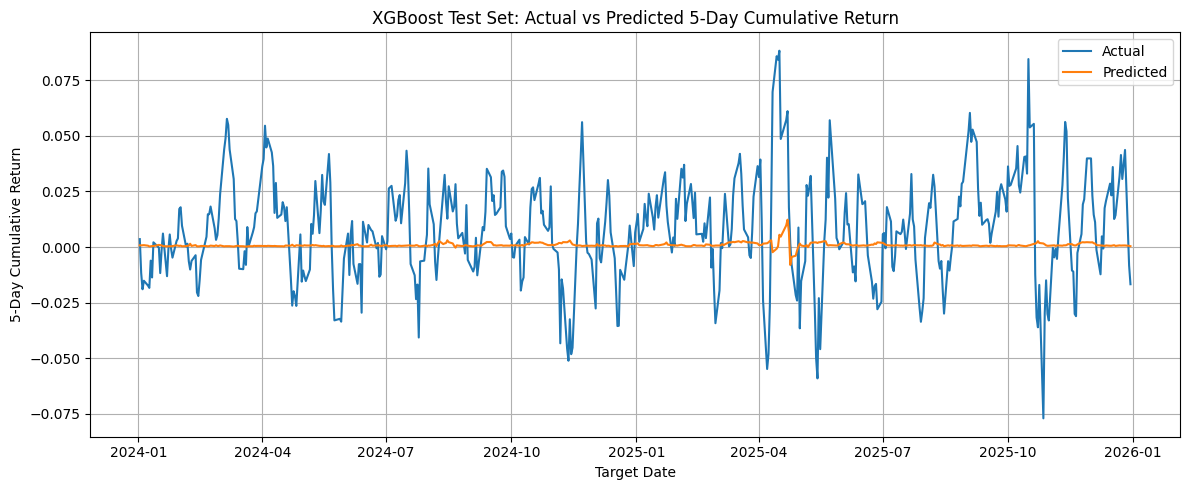

In [28]:
plot_df = final_test_pred_df.copy()
plot_df = plot_df.sort_values(TARGET_DATE_COL).reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(plot_df[TARGET_DATE_COL], plot_df[TARGET_COL], label="Actual")
plt.plot(plot_df[TARGET_DATE_COL], plot_df["PRED"], label="Predicted")
plt.title("XGBoost Test Set: Actual vs Predicted 5-Day Cumulative Return")
plt.xlabel("Target Date")
plt.ylabel("5-Day Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### **Feature Importance**

In [29]:
feature_importance_df = pd.DataFrame({
    "feature": BEST_FEATURE_COLS,
    "importance": final_model.feature_importances_,
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df.head(20))

,feature,importance
0,VIX_LEVEL_LAG5,0.038160
1,VIX_LEVEL_LAG3,0.036228
2,DXY_RET,0.033771
3,SP500_RET_LAG5,0.032780
4,VIX_LEVEL_LAG4,0.032363
5,VIX_LEVEL,0.032111
6,VIX_LEVEL_LAG6,0.031748
7,GOLD_RET_LAG3,0.029864
8,US10Y_CHANGE_LAG3,0.029292
9,GOLD_RET_LAG4,0.028445


In [30]:
feature_importance_path = RESULTS_DIR / "xgboost_feature_importance_5d.csv"
feature_importance_df.to_csv(feature_importance_path, index=False)

print("Saved:", feature_importance_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_feature_importance_5d.csv


## **Final Summary**

In [31]:
summary = {
    "model": "XGBoost",
    "target": TARGET_COL,
    "target_scale": TARGET_SCALE,
    "selection_rule": "best hyperparameters selected by Optuna using TimeSeriesSplit CV MAE; RMSE and DA used as secondary checks",
    "n_trials": N_TRIALS,
    "n_splits": N_SPLITS,
    "gap": GAP,
    "best_params": BEST_PARAMS,
    "best_package": BEST_PACKAGE,
    "best_feature_cols": BEST_FEATURE_COLS,
    "validation_metrics_best_package": {
        "MAE": float(BEST_STAGE_B["MAE"]),
        "RMSE": float(BEST_STAGE_B["RMSE"]),
        "DA": float(BEST_STAGE_B["DA"]),
    },
    "test_metrics": {
        "MAE": float(final_test_metrics["MAE"]),
        "RMSE": float(final_test_metrics["RMSE"]),
        "DA": float(final_test_metrics["DA"]),
    },
    "benchmark_metrics": {
        "ZERO": zero_metrics,
        "PERSISTENCE": persist_metrics,
    },
    "row_counts": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
        "train_plus_validation": int(len(train_val_df)),
    },
    "diagnostics": {
        "final_test": final_test_diagnostics,
    },
    "files": {
        "stage_a_results": str(stage_a_path),
        "stage_b_results": str(stage_b_path),
        "validation_predictions": str(val_pred_path),
        "test_predictions": str(test_pred_path),
        "benchmarks": str(benchmark_path),
        "feature_importance": str(feature_importance_path),
    },
}

summary_path = RESULTS_DIR / "xgboost_summary_5d.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)

Saved: C:\Users\Afzi\Documents\BINUS\0. SKRIPSI\gold_forecasting_skripsi\results\xgboost_5d\xgboost_summary_5d.json


In [32]:
print("\n===== XGBOOST 5D SUMMARY =====")
print("Train rows        :", len(train_df))
print("Validation rows   :", len(val_df))
print("Test rows         :", len(test_df))
print("Best package      :", BEST_PACKAGE)
print("Num features      :", len(BEST_FEATURE_COLS))

print("\nBest params:")
for key, value in BEST_PARAMS.items():
    print(f"- {key}: {value}")

print("\nValidation")
print(f"MAE               : {BEST_STAGE_B['MAE']:.6f}")
print(f"RMSE              : {BEST_STAGE_B['RMSE']:.6f}")
print(f"DA                : {BEST_STAGE_B['DA']:.4f}")

print("\nTest")
print(f"MAE               : {final_test_metrics['MAE']:.6f}")
print(f"RMSE              : {final_test_metrics['RMSE']:.6f}")
print(f"DA                : {final_test_metrics['DA']:.4f}")

print("\nBenchmarks")
print(f"Zero MAE          : {zero_metrics['MAE']:.6f}")
print(f"Zero RMSE         : {zero_metrics['RMSE']:.6f}")
print(f"Zero DA           : {zero_metrics['DA']:.4f}")
print(f"Persistence MAE   : {persist_metrics['MAE']:.6f}")
print(f"Persistence RMSE  : {persist_metrics['RMSE']:.6f}")
print(f"Persistence DA    : {persist_metrics['DA']:.4f}")

print("\nDiagnostics")
print(f"Prediction std    : {final_test_diagnostics['pred_std']:.10f}")
print(f"Unique preds      : {final_test_diagnostics['unique_pred_count_rounded_10']}")
print(f"Importance sum    : {final_test_diagnostics.get('feature_importance_sum', np.nan):.6f}")
print(f"Nonzero features  : {final_test_diagnostics.get('nonzero_feature_importance_count', np.nan)}")


===== XGBOOST 5D SUMMARY =====
Train rows        : 3256
Validation rows   : 250
Test rows         : 503
Best package      : NO_G3
Num features      : 40

Best params:
- n_estimators: 300
- learning_rate: 0.005352757467945076
- max_depth: 2
- min_child_weight: 2
- subsample: 0.7533935236147858
- colsample_bytree: 0.6365517758073783
- gamma: 0.3624613769935243
- reg_alpha: 0.9925499714722436
- reg_lambda: 0.5678899037764856

Validation
MAE               : 0.014775
RMSE              : 0.018682
DA                : 0.5200

Test
MAE               : 0.018767
RMSE              : 0.024214
DA                : 0.6501

Benchmarks
Zero MAE          : 0.019073
Zero RMSE         : 0.024538
Zero DA           : 0.3459
Persistence MAE   : 0.026170
Persistence RMSE  : 0.034550
Persistence DA    : 0.5308

Diagnostics
Prediction std    : 0.0010910017
Unique preds      : 485
Importance sum    : 1.000000
Nonzero features  : 40
